

# **Aprendizaje no supervisado en datos de expresión génica de cáncer de ovario (TCGA-OV)**



El cáncer de ovario representa uno de los desafíos más significativos en la oncología ginecológica debido a su alta heterogeneidad y a que frecuentemente se diagnostica en etapas avanzadas. [1]

A nivel molecular esta enfermedad no es una entidad única, sino un conjunto de subtipos con distintos perfiles de expresión genética que determina la respuesta al tratamiento. [1]

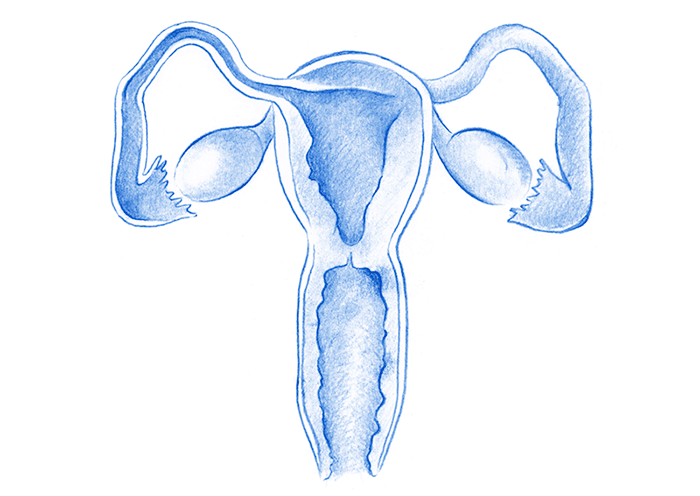

      
          Figura 1. Etapas de invasión tumoral en el tejido ovárico


          
Por lo cual, en el presente proyecto se llevará a cabo un análisis completo de de datos de expresión genética (RNAseq) y variables clínicas relacionadas al *Cáncer de Ovario* seleccionado de *TCGA* a través de la plataforma **UCSC Xena**.





## **Objetivo del estudio**

El objetivo general es aplicar técnicas de aprendizaje no supervisado (reducción de dimensionalidad con PCA y clustering con K-means y hierarchical clustering) para identificar agrupaciones naturales de pacientes basadas en su perfil de expresión genética. Posteriormente, se interpretarán estos grupos desde una perspectiva molecular y clínica.


## **Estructura del reporte**


| Sección | Contenido |
|---------|-----------|
| 1 | Planteamiento del problema y contexto de los datos |
| 2 | Exploración y comprensión del conjunto de datos |
| 3 | Preparación y tratamiento de los datos |
| 4 | Reducción de dimensionalidad mediante PCA |
| 5 | Construcción y comparación de modelos de clustering |
| 6 | Interpretación de los clusters – análisis de genes |
| 7 | Interpretación de los clusters – análisis clínico |
| 8 | Discusión con artículo científico relevante |
| 9 | Conclusión y reflexión final |


## **1. Planteamiento del problema y contexto de los datos**

###*1.1 Relevancia del problema*
El **cáncer de ovario** es una neoplasia ginecológica particularmente letal. Esta alta mortalidad se debe a una combinación riesgosa: [2]

- **Diagnóstico tardío:** En etapas iniciales, el tumor no presenta síntomas o estos son mínimos e inespecíficos, lo que dificulta el diagnóstico clínico [2].
- **Etapas avanzadas:** Como consecuencia de lo antes mencionado, entre el **70% y 80%** de los casos se identifican en fase avanzada, cuando el cáncer ya ha progresado  [2].
- **Alta incidencia:** En México, se estima que cada año afecta a más de **tres mil mujeres** [2].


### *1.2 Origen de los datos*

Los datos provienen de **The Cancer Genome Atlas (TCGA)** , accedidos a través de la plataforma **UCSC Xena**; provinientes de la base de datos: `GDC TCGA Ovarian Cancer (OV)` con los siguientes archivos locales.  


| Archivo | Contenido |
|---------|-----------|
| `TCGA-OV.star_tpm.tsv` | Expresión génica (RNAseq) en TPM (STAR pipeline) |
| `TCGA-OV.clinical.tsv` | Variables clínicas de los pacientes |
| `TCGA-OV.survival.tsv` | Datos de supervivencia (tiempo, estado) |




Destacando que, el clustering se realizará solo con datos de expresión génica. Los datos clínicos se usan posteriormente para interpretar los grupos obtenidos.




## **2. Exploración y comprensión del conjunto de datos**


En esta sección se realizará un análisis exploratorio inicial para comprender la estructura, tamaño y distribución de los datos de cáncer de ovario (TCGA-OV).

A continuación, se mostrarán  las dimensiones exactas, los tipos de datos de cada columna y un resumen estadístico básico de los tres archivos. Esto nos permitirá verificar la consistencia y alinear las muestras entre expresión y clínica.

In [23]:
import pandas as pd
import numpy as np

# Cargar los datos
expr = pd.read_csv('TCGA-OV.star_tpm.tsv', sep='\t', index_col=0)
clinical = pd.read_csv('TCGA-OV.clinical.tsv', sep='\t', index_col=0)
survival = pd.read_csv('TCGA-OV.survival.tsv', sep='\t')

print("="*70)
print("DATOS DE EXPRESIÓN GÉNICA")
print("="*70)
print(f"Dimensiones: {expr.shape[0]} genes × {expr.shape[1]} muestras")
print(f"Tipos de datos por columna:\n{expr.dtypes.value_counts()}")
print(f"\nResumen estadístico de las primeras 10 muestras (media, std, min, max):")
print(expr.iloc[:, :10].describe().round(2))

print("\n" + "="*70)
print("DATOS CLÍNICOS")
print("="*70)
print(f"Dimensiones: {clinical.shape[0]} muestras × {clinical.shape[1]} variables")
print(f"Tipos de datos por variable:\n{clinical.dtypes.value_counts()}")
print(f"\nResumen estadístico de variables numéricas:")
print(clinical.describe().round(2))

print("\n" + "="*70)
print("DATOS DE SUPERVIVENCIA")
print("="*70)
print(f"Dimensiones: {survival.shape[0]} filas × {survival.shape[1]} columnas")
print(f"Tipos de datos:\n{survival.dtypes}")
print(f"\nResumen estadístico:")
print(survival.describe().round(2))

expr_samples = set(expr.columns)
clinical_samples = set(clinical.index)
common_samples = expr_samples.intersection(clinical_samples)
print("\n" + "="*70)
print("CONSISTENCIA ENTRE EXPRESIÓN Y CLÍNICA")
print("="*70)
print(f"Muestras en expresión: {len(expr_samples)}")
print(f"Muestras en clínica: {len(clinical_samples)}")
print(f"Muestras en común: {len(common_samples)}")
if len(common_samples) < len(expr_samples):
    print(f"⚠️ Atención: {len(expr_samples) - len(common_samples)} muestras en expresión no están en clínica.")
    print(f"Ejemplo: {list(expr_samples - common_samples)[:3]}")
else:
    pass


DATOS DE EXPRESIÓN GÉNICA
Dimensiones: 60660 genes × 429 muestras
Tipos de datos por columna:
float64    429
Name: count, dtype: int64

Resumen estadístico de las primeras 10 muestras (media, std, min, max):
       TCGA-24-1104-01A  TCGA-25-1320-01A  TCGA-24-1850-01A  TCGA-61-2101-01A  \
count          60660.00          60660.00          60660.00          60660.00   
mean               1.06              1.28              1.20              1.12   
std                1.79              1.97              1.94              1.89   
min                0.00              0.00              0.00              0.00   
25%                0.00              0.00              0.00              0.00   
50%                0.12              0.22              0.13              0.12   
75%                1.36              1.83              1.65              1.38   
max               15.53             14.96             15.06             15.34   

       TCGA-23-1111-01A  TCGA-25-2396-01A  TCGA-30-1714-01A  T

Trás realizar la exploración de datos, a continuación de describirá el análisis inicial dobre los datos obtenidos de cáncer de ovario (TCGA-OV).

| Archivo | Dimensiones | Descripción |
|---------|-------------|-------------|
| **Expresión génica** (`star_tpm.tsv`) | **60,660 genes** × **429 muestras (pacientes)** | Los genes están en filas y los pacientes en columnas. Cada celda indica el nivel de expresión (TPM). |
| **Datos clínicos** (`clinical.tsv`) | **632 muestras (pacientes)** × **83 variables clínicas** | Cada fila es un paciente. Incluye información demográfica, diagnóstica, de tratamiento y seguimiento. |
| **Supervivencia** (`survival.tsv`) | **609 filas (pacientes)** × **4 columnas** | Contiene `sample` (ID de paciente), `OS.time` (días), `OS` (1=muerte, 0=censura) y `_PATIENT`. |

**Datos importantes:**
> - **Número de muestras (pacientes) en expresión:** 429  
> - **Número de variables (genes):** 60,660  
> - **Variables clínicas disponibles:** 83


Asimismo, se tienen **83 variables clínicas** en total, donde, según el resumen estadístico las más relevantes son:

- **`age_at_index.demographic`**  
 Edad al momento del consentimiento o diagnóstico inicial (años).  

- **`days_to_birth.demographic`**  
Días desde el nacimiento hasta el diagnóstico (valores negativos).  

- **`year_of_birth.demographic`**  
  Año de nacimiento del paciente.  

- **`days_to_death.demographic`**  
  Días desde el diagnóstico hasta la muerte (solo si falleció).  

- **`year_of_death.demographic`**  
  Año de fallecimiento.  

- **`days_to_last_follow_up.diagnoses`**  
  Días desde el diagnóstico hasta el último seguimiento.  

- **`age_at_diagnosis.diagnoses`**  
  Edad al diagnóstico (expresada en días).  

- **`year_of_diagnosis.diagnoses`**  
  Año del diagnóstico.  

- **`age_at_earliest_diagnosis_in_years.diagnoses.xena_derived`**  
   Edad al diagnóstico más temprano (años).  

- **`sample_type_id.samples`**  
  Tipo de muestra (1 = tumor primario, 11 = tejido normal, etc.).  

- **`intermediate_dimension.samples`**  
 Dimensión intermedia del tumor (cm).  

- **`shortest_dimension.samples`**  
  Dimensión más corta del tumor (cm).  

- **`longest_dimension.samples`**  
 Dimensión más larga del tumor (cm).  


Siendo importante destacar que hay variables categóricas no incluidas que se explorarán durante la interpretación de los clusters.

### *2.1 Revisión inicial de los datos*

A continuación se realizará una revisión para analizar las características de los datos de expresión (TPM), considerando lo siguiente:

* Identificación de valores faltantes: Se cuantificarán los datos ausentes, posteriormente evaluándose estrategias de manejo.
* Detección de valores atípicos: Se identificarán genes o muestras con comportamientos extremos que podrían distorsionar los resultados.
* Análisis de distribuciones: Se examinará la forma, centro y dispersión de los niveles de expresión génica mediante estdísticos de resumen.

Buscando así que los datos estésn en buenas condiciones para las etapas posteriores de reducción de dimensionalidad (PCA), contrucción de modelos de clustering e interpretación.

#### *2.1.1 Identificación de valores faltantes*

Para identificar los valores ausentes en el conjunto de datos de expresión génica (TPM), se identificarán los valores no disponibles (NaN). Permitiéndonos evaluar el manejo más adecuado.



In [24]:
# 2.1.1 Identificación de valores faltantes en expresión TPM
import pandas as pd
import numpy as np

# Cargar expresión (si no está cargada)
expr = pd.read_csv('TCGA-OV.star_tpm.tsv', sep='\t', index_col=0)

total_celdas = expr.size
faltantes = expr.isnull().sum().sum()
porcentaje = (faltantes / total_celdas) * 100

print("="*50)
print("VALORES FALTANTES EN LA MATRIZ DE EXPRESIÓN")
print("="*50)
print(f"Total de celdas (genes × muestras): {total_celdas}")
print(f"Número de valores faltantes (NaN): {faltantes}")
print(f"Porcentaje de faltantes: {porcentaje:.4f}%")

if faltantes == 0:
    print("\n✅ Conclusión: No hay valores faltantes. La matriz está completa.")
else:
    print("\n⚠️ Se detectaron valores faltantes. Se analizará por gen y muestra.")
    # Análisis adicional por gen
    faltantes_por_gen = expr.isnull().sum(axis=1)
    genes_con_faltantes = faltantes_por_gen[faltantes_por_gen > 0]
    print(f"Genes con al menos un faltante: {len(genes_con_faltantes)}")
    print(f"Máximo de faltantes en un gen: {genes_con_faltantes.max()} muestras")
    # Análisis por muestra
    faltantes_por_muestra = expr.isnull().sum(axis=0)
    muestras_con_faltantes = faltantes_por_muestra[faltantes_por_muestra > 0]
    print(f"Muestras con al menos un faltante: {len(muestras_con_faltantes)}")
    print(f"Máximo de faltantes en una muestra: {muestras_con_faltantes.max()} genes")

VALORES FALTANTES EN LA MATRIZ DE EXPRESIÓN
Total de celdas (genes × muestras): 26023140
Número de valores faltantes (NaN): 0
Porcentaje de faltantes: 0.0000%

✅ Conclusión: No hay valores faltantes. La matriz está completa.


Los resultados nos indican que no es necesario aplicar estrategias de imputación o eliminación de muestras/genes por ausencia de datos. Por lo cual, será posible proceder con el análisis de distribuciones.



#### *2.1.2 Detección de valores atípicos*


El rango intercuartílico (IQR) es la diferencia entre el percentil 75 (Q3) y el percentil 25 (Q1). Considerándosele un valor atípico a aquel que se encuentra por debajo de **Q1 - 1.5 × IQR** o por encima de **Q3 + 1.5 × IQR**. [3]

Se aplicará por muestra usando la media de expresión de cada paciente y por gen usando la varianza de expresión de cada gen. Esto será aplicado debido a que los outliers detectados podrían distorsionar el clustering, por lo que se evaluará si se imputará o eliminará.

In [25]:
sample_means = expr.mean(axis=0)
Q1 = np.percentile(sample_means, 25)
Q3 = np.percentile(sample_means, 75)
IQR = Q3 - Q1
lower = Q1 - 1.75 * IQR
upper = Q3 + 1.75 * IQR
outliers = sample_means[(sample_means < lower) | (sample_means > upper)]

print(f"Límites: [{lower:.4f}, {upper:.4f}]")
print(f"Muestras outlier: {len(outliers)}")
if len(outliers) > 0:
    print("Lista de muestras con media atípica:")
    for sample, val in outliers.items():
        print(f"  {sample}: {val:.4f}")
else:
    pass


Límites: [0.8325, 1.4803]
Muestras outlier: 1
Lista de muestras con media atípica:
  TCGA-61-2088-01A: 1.4973


Tras aplicarse el análisis de valores atípicos en muestras se observa que solo una paciente se presenta como valor atípico. Por ello, no se le eliminará del análisis, pero se le dará seguimiento durante el clustering para evaluar su influecia en los resultados.

#### *2.1.3 Análisis básico de distribuciones*

Para comprender la forma y dispersión de los niveles de expresión génica, se calcularán estadísticos resumen (media, mediana, desviación estándar, percentiles) y se generarán histogramas para su posterior análisis. Resaltando que, dado que algunos genes tienen expresión baja, nula o muy alta, se comparará la escala original con un transformación logarítmica (`log1p`) para visualizar mejor la forma.

📈 ANÁLISIS DE DISTRIBUCIONES - TPM
Media: 1.1599
Mediana: 0.1367
Desviación estándar: 1.8899
Mínimo: 0.0000
Máximo: 17.1311
Percentil 25: 0.0000
Percentil 75: 1.5717
Coeficiente de asimetría (skewness): 1.95


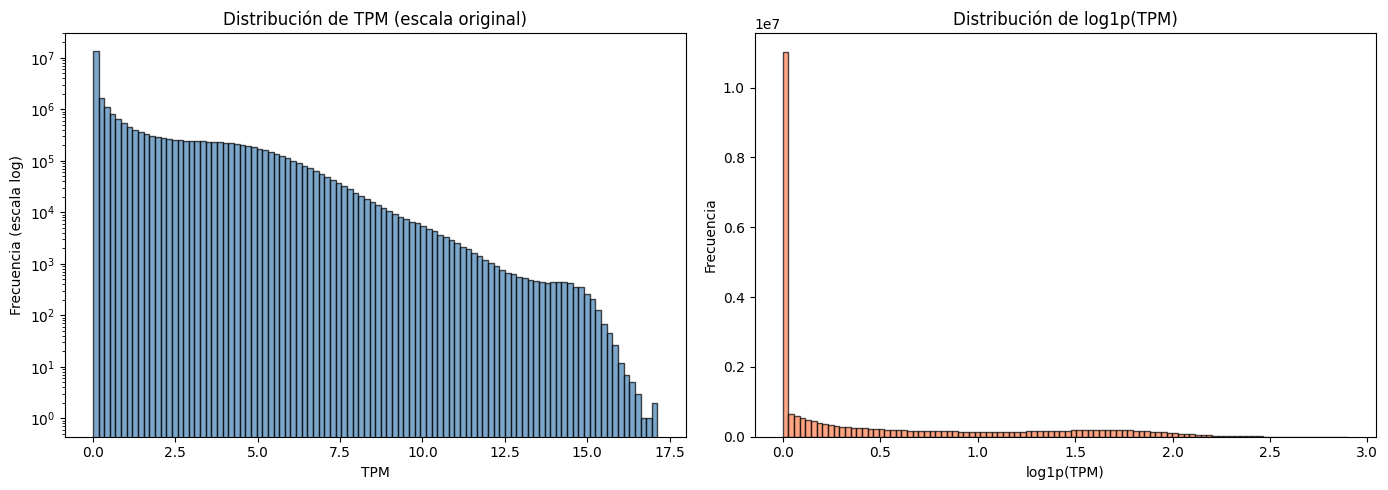

In [26]:
# 2.1.2 Análisis básico de distribuciones
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Usamos la variable 'expr' cargada anteriormente
vals = expr.values.flatten()

print("="*60)
print("📈 ANÁLISIS DE DISTRIBUCIONES - TPM")
print("="*60)

# Estadísticos resumen
print(f"Media: {np.mean(vals):.4f}")
print(f"Mediana: {np.median(vals):.4f}")
print(f"Desviación estándar: {np.std(vals):.4f}")
print(f"Mínimo: {np.min(vals):.4f}")
print(f"Máximo: {np.max(vals):.4f}")
print(f"Percentil 25: {np.percentile(vals, 25):.4f}")
print(f"Percentil 75: {np.percentile(vals, 75):.4f}")
print(f"Coeficiente de asimetría (skewness): {float(pd.Series(vals).skew()):.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma en escala original (con eje y log para mejor visualización)
axes[0].hist(vals, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribución de TPM (escala original)', fontsize=12)
axes[0].set_xlabel('TPM')
axes[0].set_ylabel('Frecuencia (escala log)')
axes[0].set_yscale('log')

# Histograma con log1p
log_vals = np.log1p(vals)
axes[1].hist(log_vals, bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribución de log1p(TPM)', fontsize=12)
axes[1].set_xlabel('log1p(TPM)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()



De esta forma, el análisis de valores TPM permitió identificar una alta variabilidad en los niveles de expresión génica de las muestras de cáncer de ovario.

Viéndose con una media de alrededor de 1.15 y una mediana menor de 0.1367, indicando una distribución asimétrica. Viéndose en el coeficiente de asimetría de 1.95, demostrando que los genes presentan niveles bajos o nulos, mientras que otro grupo cuanta con expresiones altas. De igual forma en los percentiles que muestran que el 25% de los datos cuentan con valores iguales o cercanos a cero; mientras que el 75% se encuentra por debajo de 1.5717, demostrando la concentración de genes.

Mientras que el histograma de la escala original se observa claramente esta concentración en valores pequeños y una cola hacia valores altos. Debido a esta dispersión, se aplicó la transformación logarítmica log1p(TPM), la cual reduce el efecto de los valores muy altos y comprime la escala de los datos.


## **3. Preparación y tratamiento de los datos**


En esta sección se describirán y justificarán las estrategias implementadas para la preparación de datos, incluyendo el manejo de valores faltantes, normalización de expresiones génicas y filtrado de genes con poca relevancia informativa.

Donde, más allá de la interpretación técnica, se busca explicar la razón detrás de las metodologías utilizadas.

#### *3.1. Manejo de valores faltantes*

Como se identificó en la Sección 2, el conjunto de datos no cuenta conn valores faltantes. Por lo tanto, no se aplicará ninguna estrategia de imputación ni eliminación de muestras o genes por esta causa. Decidiendose conservar las muestras y genes originales en las siguientes etapas.

#### *3.2. Consideración sobre valores atípicos*

Durante la exploración inicial (Sección 2.1.2) se identificó **una muestra** (`TCGA-61-2088-01A`) con una media ligeramente superior al límite superior establecido mediante IQR. Si bien este valor se considera un outlier, se decidió **no eliminar la muestra** debido a que eliminar una muestra sin evidencia de que este sea un error técnico podría eliminar información biológica relevante.

Por ello, la transformación `log1p` que se aplicará en la siguiente sección comprimirá la escala de los valores altos, reduciendo el impacto de este outlier.

#### *3.3. Transformación de los datos*

Los datos de RNA presentan una distribución altamente asimétrica con cola derecha y un coeficiente de asimetría de 1.95.

Por lo tanto, para hacer que estos datos se aproximen a una distribución normal y estabilizar la varianza, se aplicará la **transformación logarítmica `log1p`**. Esto nos permitirá que los genes con una expresión baja tengan una escala comparable.

In [27]:


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


expr_log = np.log1p(expr)
print("\n✅ Paso 1: Transformación log1p(TPM)")
print(f"   Rango de valores después de log1p: [{expr_log.min().min():.4f}, {expr_log.max().max():.4f}]")
print(f"   Media global: {expr_log.mean().mean():.4f}, Mediana global: {expr_log.median().median():.4f}")




✅ Paso 1: Transformación log1p(TPM)
   Rango de valores después de log1p: [0.0000, 2.8976]
   Media global: 0.5073, Mediana global: 0.1313


#### *3.4. Filtrado de genes de baja varianza*

Algunos genes no son considerados útiles para crear las distintas agrupaciones; esto debido a que los que cuentan con varianza cercana a cero no contribuyen significativamente en la construcción de clusters, añadiendo ruido al análisis.

Por lo tanto, al contar los  60,660  genes y eliminarse los de varianza cero reduce la dimensionalidad sin perder de información relevante.

In [28]:

varianza_por_gen = expr_log.var(axis=1)
genes_con_varianza_cero = varianza_por_gen[varianza_por_gen == 0].index
print(f"\n✅ Paso 2: Filtrado de varianza cero")
print(f"   Número de genes con varianza cero (expresión constante): {len(genes_con_varianza_cero)}")
expr_log_filtrado = expr_log.drop(index=genes_con_varianza_cero)
print(f"   Nuevo número de genes: {expr_log_filtrado.shape[0]}")
print(f"   Muestras restantes: {expr_log_filtrado.shape[1]} (sin cambios)")




✅ Paso 2: Filtrado de varianza cero
   Número de genes con varianza cero (expresión constante): 2835
   Nuevo número de genes: 57825
   Muestras restantes: 429 (sin cambios)


Como parte del proceso de preparación de datos, mtras realizar un filtrado de genes de varianza baja, se identificaron y eliminaron 2835 genes de este tipo logrando redicir el conjunto de datos de  60,660  a 57,825 genes. Indicando así que esta proporción de genes no aportaba variabilidad al análisis.

Esto se llevó a cabo debido a que este tipo de variables no contiene información útil que nos permita distinguir las diferencias biológicas entre las muestras de cáncer de ovario. Incrementando de manera inecesaria la dimensionalidad del conjunto de datos y agregando ruido al modelo. Por ello, se optó por mantener únicamente los genes que pueden brindar información relevante.

## **4. Reducción de dimensionalidad mediante PCA**

El Análisis de Componentes Principales (PCA) es una técnica lineal que transforma las variables originales (genes) en un nuevo conjunto de **componentes principales** ortogonales, ordenados por la cantidad de varianza que explican. [4]

 Esto debido a que este tipo de conjunto de datos contiene una gran cantidad de variables, por lo tanto, con PCA es posible resumir la variabilidad de los datos en un número reducido de componentes principales. [4]

 #### *4.1 Análisis de la varianza explicada*

 Se calculó la **proporción de varianza explicada** por cada componente principal y la **varianza acumulada**.

 Esto nos permite evaluar cuántos componentes son necesarias para resumir la mayor parte de la variabilidad de los datos, con apoyo de un scree plot.[5]


Dimensiones: 57825 genes × 429 muestras
Varianza explicada por las primeras 10 componentes:
PC1: 0.1093 (10.93%)
PC2: 0.0584 (5.84%)
PC3: 0.0373 (3.73%)
PC4: 0.0243 (2.43%)
PC5: 0.0234 (2.34%)
PC6: 0.0161 (1.61%)
PC7: 0.0147 (1.47%)
PC8: 0.0136 (1.36%)
PC9: 0.0125 (1.25%)
PC10: 0.0116 (1.16%)

Varianza acumulada hasta PC10: 0.3211 (32.11%)


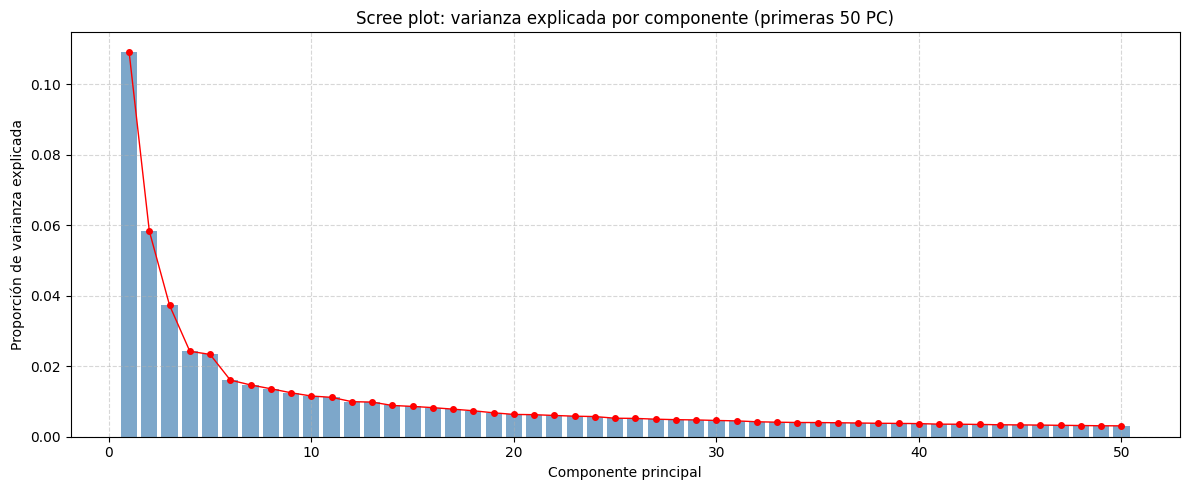

In [29]:
expr_prep = expr_log_filtrado
print(f"Dimensiones: {expr_prep.shape[0]} genes × {expr_prep.shape[1]} muestras")

# 4.1 Varianza explicada y scree plot
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt


if expr_prep.isnull().any().any():
    initial_genes = expr_prep.shape[0]
    expr_prep = expr_prep.dropna(axis=0)


# Transponer: PCA espera muestras × características
X = expr_prep.T

# Aplicar PCA
pca = PCA()
pca_scores = pca.fit_transform(X)

# Varianza explicada
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("="*60)
print("Varianza explicada por las primeras 10 componentes:")
print("="*60)
for i in range(10):
    print(f"PC{i+1}: {explained_var[i]:.4f} ({explained_var[i]*100:.2f}%)")
print(f"\nVarianza acumulada hasta PC10: {cumulative_var[9]:.4f} ({cumulative_var[9]*100:.2f}%)")

# Scree plot (primeras 50 componentes)
plt.figure(figsize=(12, 5))
plt.bar(range(1, 51), explained_var[:50], alpha=0.7, color='steelblue')
plt.plot(range(1, 51), explained_var[:50], 'ro-', linewidth=1, markersize=4)
plt.title('Scree plot: varianza explicada por componente (primeras 50 PC)')
plt.xlabel('Componente principal')
plt.ylabel('Proporción de varianza explicada')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Tras el el análisis de componentes principales (PCA) realizado sobre el conjunto de datos, fue posible observar la variabilidad dentro de los datos. Los resultados muestran que la primera componente principal (PC1) explica el 10.93% de la varianza total, mientras que la segunda componente (PC2) explica un 5.84%. A partir de la tercera componente, el porcentaje explicada disminuye progresivamente, indicando que la información se encuentra distribuida entre múltiples componentes.

Así, al analizar las primeras diez componentes se alcanza un 32.11%, indicando que existe una gran complejidad entre las muestras de cáncer de ovario, ya que la variabilidad depende de muchos genes y procesos biológicos simultáneamente.

 #### *4.2 Justificación del número de componentes seleccionados*

Para decidir cuántos componentes usar en el clustering, se utiliza el **criterio de varianza acumulada** (80% o 90%) y el **punto de codo** del scree plot.

Por lo tanto, en la siguiente celda se calcula el número de componentes necesarios para alcanzar ciertos umbrales.


Número de componentes necesarios para explicar la varianza acumulada:
  70% → 130 componentes
  80% → 203 componentes
  85% → 248 componentes
  90% → 299 componentes
  95% → 357 componentes

Varianza acumulada con PC20: 0.4061 (40.61%)
Varianza acumulada con PC50: 0.5330 (53.30%)


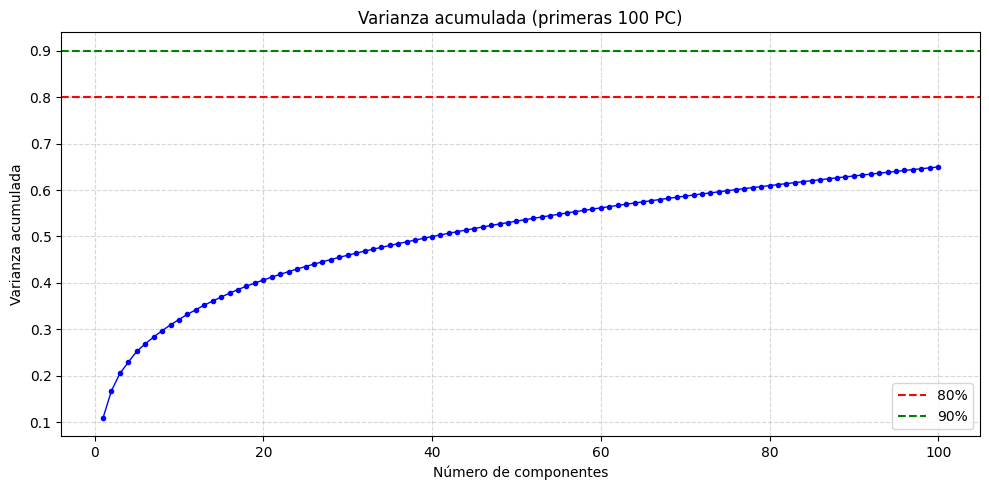

In [30]:
# 4.2 Número de componentes para alcanzar umbrales de varianza acumulada
umbrales = [0.7, 0.8, 0.85, 0.9, 0.95]
print("="*60)
print("Número de componentes necesarios para explicar la varianza acumulada:")
print("="*60)
for umbral in umbrales:
    n_comp = np.argmax(cumulative_var >= umbral) + 1
    print(f"  {umbral*100:.0f}% → {n_comp} componentes")
print(f"\nVarianza acumulada con PC20: {cumulative_var[19]:.4f} ({cumulative_var[19]*100:.2f}%)")
print(f"Varianza acumulada con PC50: {cumulative_var[49]:.4f} ({cumulative_var[49]*100:.2f}%)")

# Gráfico de varianza acumulada (primeras 100 componentes)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), cumulative_var[:100], 'bo-', linewidth=1, markersize=3)
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.axhline(y=0.9, color='g', linestyle='--', label='90%')
plt.title('Varianza acumulada (primeras 100 PC)')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Asimismo, al analizar la varianza acumulada se observa que los datos de expresión génica son bastante complejos, ya que la información está distribuida en mcuhos componentes principales.

Son necesarios 130 componentes para explicar el 70% de la varianza total, mientras que 203 y 299 componentes permiten conservar el 80% y 90%, respectivamente. Además, las primeras 20 componentes explican el 40.61% de la varianza.

Por lo tanto, para una visualización general utilizaría alrededor de 50 componentes, ya que reduce la dimensionalidad manteniendo información con relevante. Sin embargo, para lograr un análisis más detallado, se trabajará con alrededor de 299 componentes es una opción apropiada al conservar aproximadamente el 90% de la variabilidad original.

 #### *4.3 Visualización de los datos en espacios de menor dimensión*

Por ello, Se proyectarán los pacientes en los primeros componentes para explorar agrupamientos naturales.
- **PC1 vs PC2** (principales)
- **PC1 vs PC3** (para explorar variabilidad)

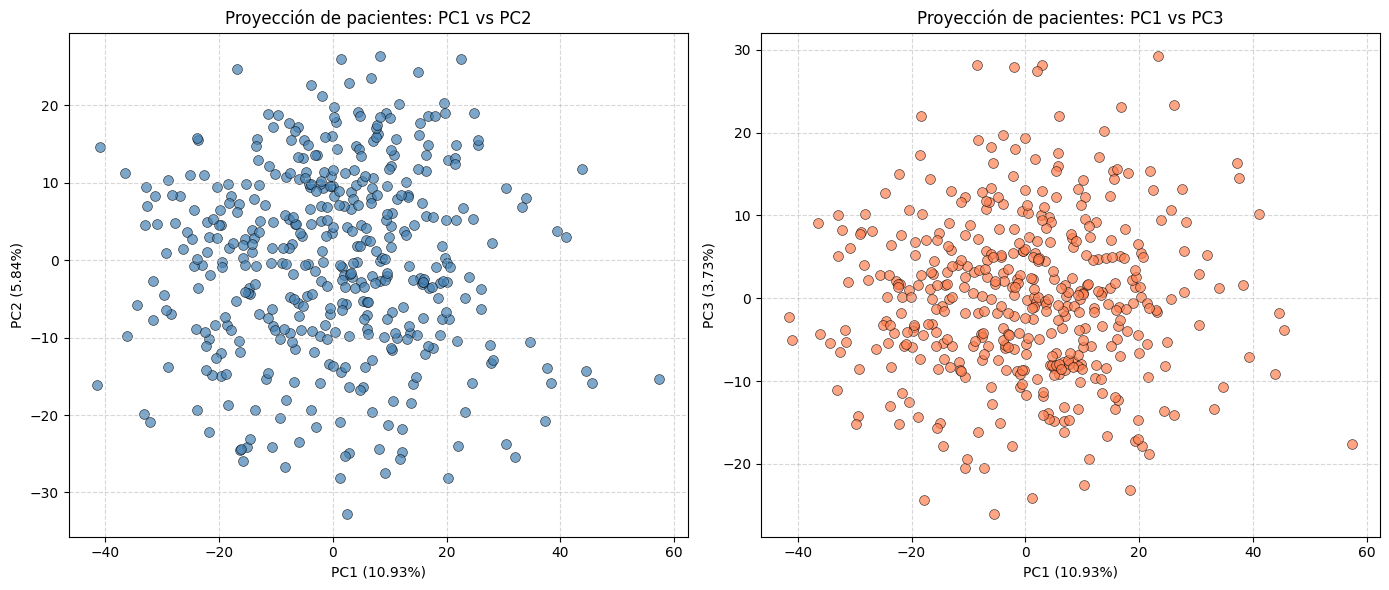


✅ Primeras 50 componentes guardadas en 'pca_df' para clustering.


In [31]:

plt.figure(figsize=(14, 6))

# Gráfico PC1 vs PC2
plt.subplot(1, 2, 1)
plt.scatter(pca_scores[:, 0], pca_scores[:, 1], alpha=0.7, s=50, c='steelblue', edgecolor='k', linewidth=0.5)
plt.title('Proyección de pacientes: PC1 vs PC2')
plt.xlabel(f'PC1 ({explained_var[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({explained_var[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.5)

# Gráfico PC1 vs PC3
plt.subplot(1, 2, 2)
plt.scatter(pca_scores[:, 0], pca_scores[:, 2], alpha=0.7, s=50, c='coral', edgecolor='k', linewidth=0.5)
plt.title('Proyección de pacientes: PC1 vs PC3')
plt.xlabel(f'PC1 ({explained_var[0]*100:.2f}%)')
plt.ylabel(f'PC3 ({explained_var[2]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

pca_df = pd.DataFrame(pca_scores[:, :50], index=X.index, columns=[f'PC{i+1}' for i in range(50)])
print("\n✅ Primeras 50 componentes guardadas en 'pca_df' para clustering.")

La proyección de las muestras por las componentes principales PC1 vs PC2 y PC1 vs PC3 muestra que la mayoría de los pacientes se concentra alrededor del área central, mientras que otros puntos aparecen más dispersos alrededor de esta zona.

 No se observan agrupamientos claramente separados entre grupos, sugiriendo que las diferencias en los perfiles de expresión génica no generan una separación evidente en las primeras componentes principales. Por lo cual, podrían necesitarse más componentes o técnicas adicionales de clustering para identificar patrones más específicos.

## **5. Construcción y comparación de modelos de clustering**


 #### *5.1 Preparación de los datos para clustering*

En esta sección se llevará a cabo la construcción de modelos de clustering, por lo tanto, usaremos  las primeras 299 componentes principales. Permitiendonos reducir la dimensionalidad eliminando ruido y manteniendo el 90% de la varianza.


In [32]:

n_components_90 = 299  # ajusta si tu número fue diferente
X_cluster = pca_scores[:, :n_components_90]
print(f"Matriz para clustering: {X_cluster.shape[0]} muestras × {X_cluster.shape[1]} componentes")

Matriz para clustering: 429 muestras × 299 componentes


 #### *5.2 Determinación del número óptimo de clusters (k)*

Antes de aplicar los algoritmos de clustering K-means y clustering jerárquico, es necesario determinar el número adecuado de grupos (k) que mejor representara la estructura de los datos.

Esto es esencial, ya que un número demasiado pequeño puede agrupar muestras diferentes dentro del mismo cluster, mientras que un valor excesivo puede generar sobreajuste en datos.

Por ello se usarán los siguientes métodos:

* **El método del codo**: este se encarga en evaluar cómo disminuye la inercia o variabilidad interna de los clusters conforme aumenta el número de grupos, buscando el punto donde la mejora comienza a estabilizarse. [5]

* **Coeficiente de silueta**: mide qué tan similares son las muestras dentro de su propio cluster en comparación con otros clusters, permitiendo evaluar la calidad de la separación entre grupos. [6]


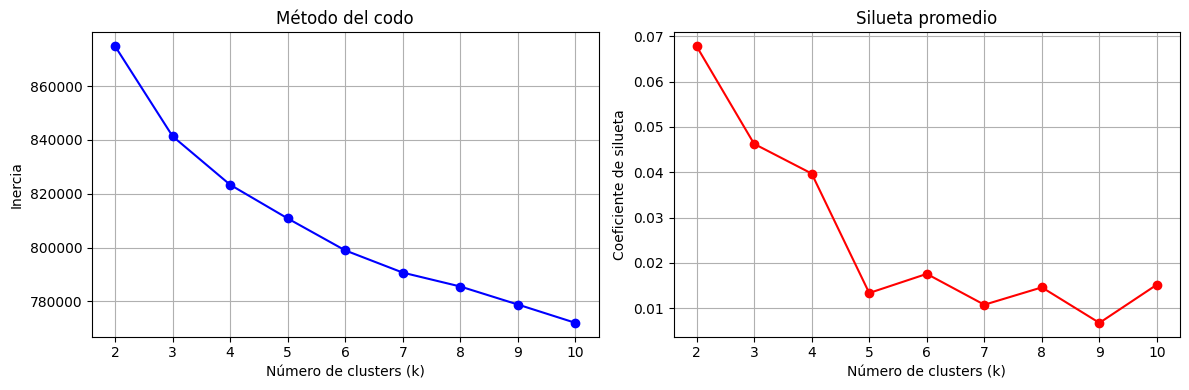

k	Inercia		Silueta
2	874851.45		0.0678
3	841363.56		0.0463
4	823347.92		0.0397
5	810832.23		0.0134
6	798954.74		0.0176
7	790700.64		0.0108
8	785539.08		0.0146
9	778840.99		0.0068
10	772024.55		0.0152


In [33]:
# 5.1 Determinación del número óptimo de clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inercia = []
siluetas = []
k_range = range(2, 11)  # probar k de 2 a 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inercia.append(kmeans.inertia_)
    sil = silhouette_score(X_cluster, kmeans.labels_)
    siluetas.append(sil)

# Gráfico del codo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(k_range, inercia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)

# Gráfico de silueta
plt.subplot(1, 2, 2)
plt.plot(k_range, siluetas, 'ro-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de silueta')
plt.title('Silueta promedio')
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar valores
print("k\tInercia\t\tSilueta")
for k, iner, sil in zip(k_range, inercia, siluetas):
    print(f"{k}\t{iner:.2f}\t\t{sil:.4f}")

Los resultados del método del codo muestran que se disminuye progresivamente conforme aumenta el número de clusters. Presentando una reducción más significativa entre $k = 2$ y $k=4$, mientras que a partir de valores mayores la mejora comienza a ser menos pronunciada Indicando que el codo de la curva podría encontrarse aproximadamente entre 3 y 4 clusters.

Por su parte, el coeficiente de silueta presenta sus valores más altos en $k = 2$ (0.0678) y  $k = 3$ (0.0463), disminuyendo considerablemente para valores mayores en $k$. Cabe destacar que, a pesar de que los valores de silueta son relativamente bajos en general, esto es común en datos biológicos complejos como los de expresión génica.

Tras analizar los resultados mediante ambos métodos, se decide utilizar $k = 3$ (0.0463), ya que representa un equilibrio entre una reducción adecuada de la inercia y separación entre grupos. Buscando evitar agrupamientos artificiales considerando nuestros datos que cuentan con alta heterogeneidad.

#### *5.3 Aplicación de K-means*

Una vez seleccionado el número de clusters (k = 3), se aplicará el algoritmo K-Means con el objetivo de identificar agrupamientos entre las muestras. K-Means nos permitirá agrupar las muestras según su similitud, buscanso minimizar la distancia entre los puntos que pertenecen a un mismo cluster y maximizar la separación entre grupos diferentes. [7]

De esta manera, buscando mejorar la estabilidad en resultados se utilizará una inicialización múltiple de 10, así, se reduce el riesgo de converger en soluciones subóptimas tras la inicialización aleatoria de centroides. Además, se incorporarán las etiquetas generadas por el algoritmo a un DataFrame que facilitará posteriores análisis comparativos.

In [34]:
# 5.2 K-means con el k seleccionado
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_cluster)

# Agregar etiquetas a un dataframe de muestras
resultados = pd.DataFrame(index=X.index)
resultados['cluster_kmeans'] = kmeans_labels
print(f"Asignación de clusters (K-means):\n{resultados['cluster_kmeans'].value_counts().sort_index()}")

Asignación de clusters (K-means):
cluster_kmeans
0    142
1    114
2    173
Name: count, dtype: int64


En los resultados se observa que el algoritmo K-Means permitió dividir las 429 muestras en tres clusters de manera relativamente balanceada.El cluster 0 quedó conformado por 142 muestras, el cluster 1 por 114 muestras y el cluster 2 por 173 muestras.

Esto indica que el algoritmo identificó grupos con una cantidad considerable de pacientes, evitando clusters demasiado pequeños. Por lo cual, podemos determinar que existen patrones de similitud enttre los distintos perfiles. Sin embargo, no necesariamente representan separaciones completamente definidas, principalmente poor la naturaleza compleja de los datos de cáncer de ovario.

#### *5.4 Aplicación de Hierarchical Clustering*

Ahora, se aplicará clustering jerárquico con el objetivo de explorar la estructura de similitud entre las muestras desde una perspectiva jerárquica. Este método consiste en agrupar progresivamente las observaciones según su cercanía, generando una estructura en forma de árbol denominada dendrograma, la cual permite visualizar cómo se forman los grupos y las relaciones existentes entre ellos. [8]

Para este análisis se utilizará el método de Ward junto con la distancia euclidiana. El método de Ward busca minimizar la varianza intra-cluster en cada etapa de agrupamiento, formando clusters más compactos y homogéneos. [8]

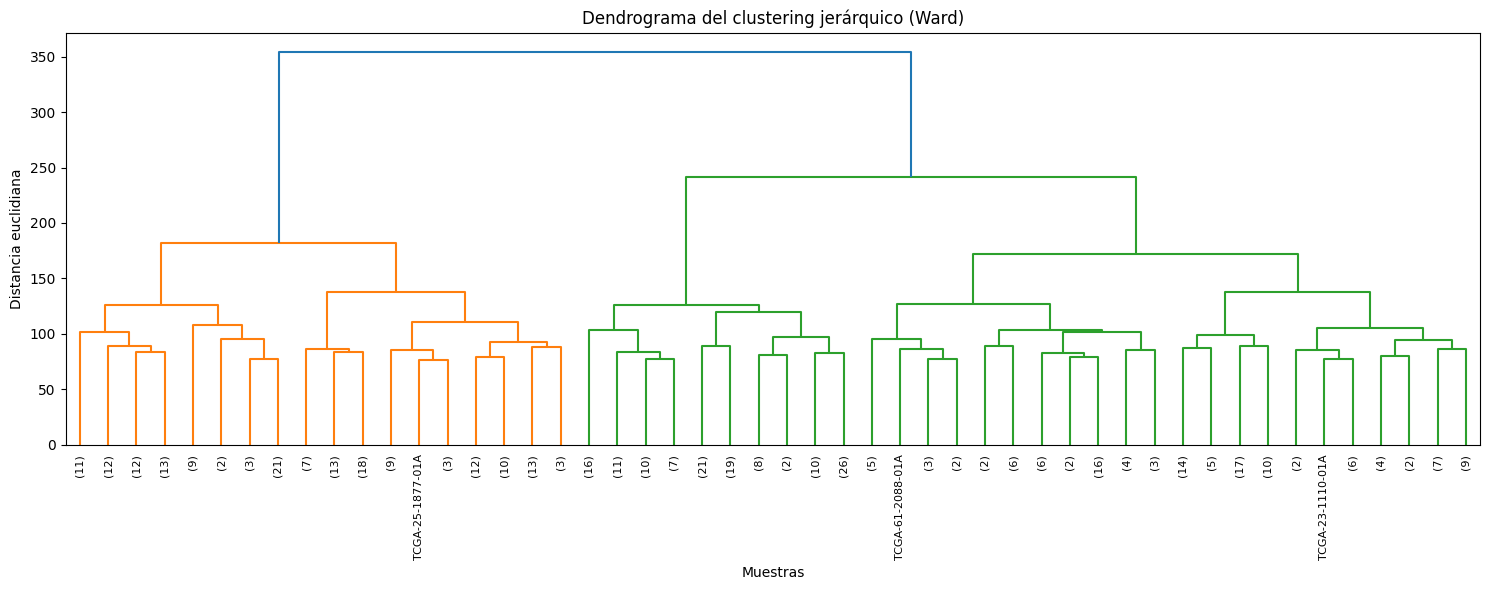

Asignación de clusters (Jerárquico):
cluster_hier
0    172
1    130
2    127
Name: count, dtype: int64


In [35]:
# 5.3 Clustering Jerárquico
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Calcular la matriz de enlace (linkage)
Z = linkage(X_cluster, method='ward', metric='euclidean')

# Dendrograma (mostrar hasta 50 etiquetas para no saturar)
plt.figure(figsize=(15, 6))
dendrogram(Z, labels=X.index, leaf_rotation=90, leaf_font_size=8, truncate_mode='lastp', p=50)
plt.title('Dendrograma del clustering jerárquico (Ward)')
plt.xlabel('Muestras')
plt.ylabel('Distancia euclidiana')
plt.tight_layout()
plt.show()

# Cortar el dendrograma para obtener k clusters (usar el mismo k_optimo)
hier_labels = fcluster(Z, t=k_optimo, criterion='maxclust')
resultados['cluster_hier'] = hier_labels - 1  # restar 1 para que empiece en 0
print(f"Asignación de clusters (Jerárquico):\n{resultados['cluster_hier'].value_counts().sort_index()}")

Tras el clustering jerárquicp fue posible dividir las 429 muestras en tres grupos con tamaños de 172, 130 y 127 muestras, respectivamente.

 A diferencia de K-means, donde los clusters resultaron más balanceados, en este caso se observa un cluster de mayor tamaño. Esto indica que, bajo el método de Ward, existe un grupo de pacientes con perfiles de expresión génica más similares entre sí, mientras que los otros dos clusters se diferencian más.

#### *5.5 Comparación de los modelos de clustering*

De esta manera, buscando evaluar y comparar los agrupamientos obtenidos mediante K-means y clustering jerárquico, se realizará una visualización de las muestras proyectadas sobre las dos primeras componentes principales (PC1 y PC2) obtenidas mediante PCA.

 Esta representación permitirá observar de manera simplificada cómo se distribuyen los clusters en un espacio de menor dimensión, facilitando así la identificación de patrones entre ambos métodos de agrupamiento.

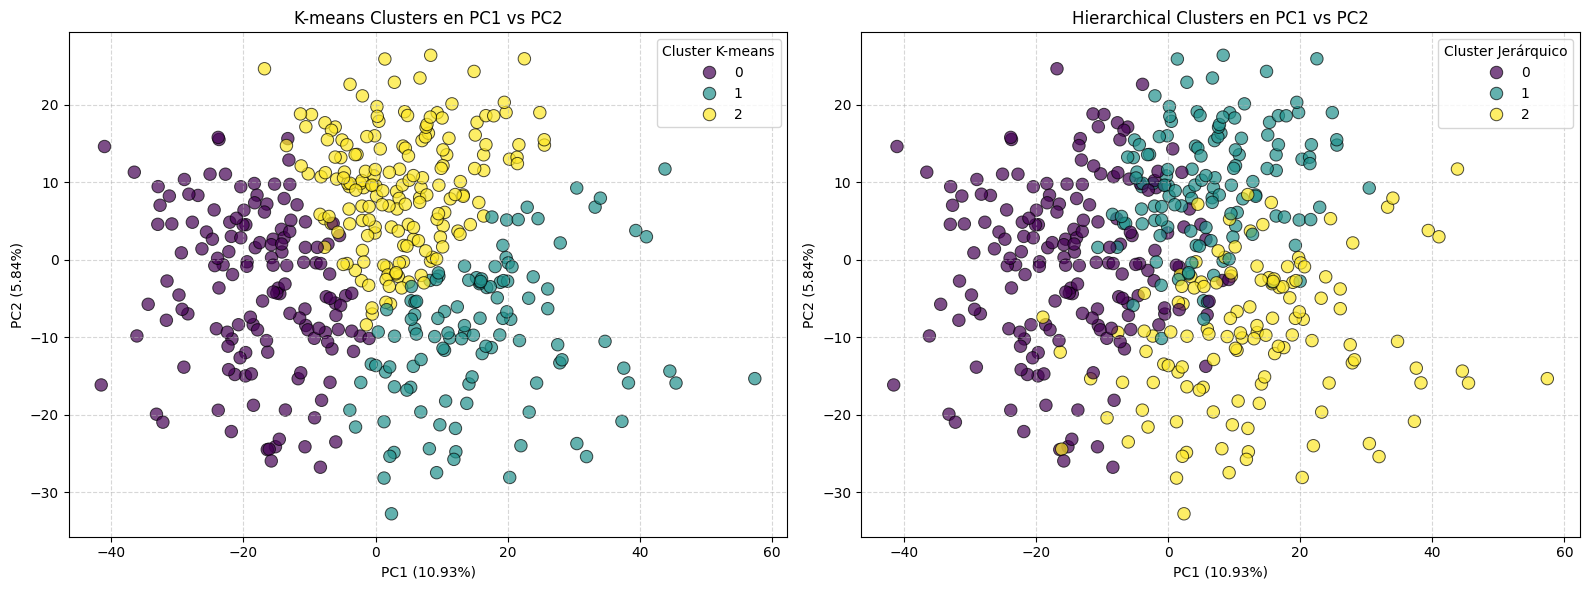

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Aumentar el ancho para que quepan ambos

# 5.5.1 Visualización de clusters K-means en PC1 vs PC2
sns.scatterplot(x=pca_scores[:, 0], y=pca_scores[:, 1], hue=kmeans_labels, palette='viridis', s=80, alpha=0.7, edgecolor='k', ax=axes[0])
axes[0].set_title('K-means Clusters en PC1 vs PC2')
axes[0].set_xlabel(f'PC1 ({explained_var[0]*100:.2f}%)')
axes[0].set_ylabel(f'PC2 ({explained_var[1]*100:.2f}%)')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(title='Cluster K-means')

# 5.5.2 Visualización de clusters Jerárquicos en PC1 vs PC2
sns.scatterplot(x=pca_scores[:, 0], y=pca_scores[:, 1], hue=resultados['cluster_hier'], palette='viridis', s=80, alpha=0.7, edgecolor='k', ax=axes[1])
axes[1].set_title('Hierarchical Clusters en PC1 vs PC2')
axes[1].set_xlabel(f'PC1 ({explained_var[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({explained_var[1]*100:.2f}%)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Cluster Jerárquico')

plt.tight_layout()
plt.show()

Con la visualización de los componentes principales es posible observar las agrupaciones realizadas por K-Means y Clustering Jerárquico.

En el caso de K-means, los tres clusters presentan una separación más definida dentro del espacio PC1 vs PC2, observándose grupos relativamente compactos y distribuidos en distintas regiones del plano.

Por otro lado, en el clustering jerárquico también se distinguen agrupamientos generales; sin embargo, uno de los clusters muestra una mayor dispersión y superposición con los demás grupos, particularmente el cluster 2.

#### *5.5  Similitudes y diferencias*

* Ambos métodos identificaron la presencia de tres agrupamientos principales dentro de las muestras de cáncer de ovario, indicando que existen patrones de similitud.

* K-means generó clusters más compactos y visualmente mejor separados, especialmente en la proyección PC1 vs PC2, lo que facilita la interpretación de los grupos obtenidos.

* El clustering jerárquico presentó una mayor dispersión y superposición entre algunos clusters, particularmente en el cluster 2, reflejando una separación menos definida entre muestras.

* La presencia de dispersión en ambos métodos es esperada debido a la alta heterogeneidad biológica en el conjunto de datos.

* Los resultados sugieren que K-means ofrece una segmentación más clara para este conjunto de datos, aunque el clustering jerárquico aporta información  sobre las jerarquías entre las muestras.

## **6. Análisis de genes expresados entre clusters**

Por su parte, tras los resultados de la sección anterior, se ha seleccionado el modelo de **K-means** (con $k=3$ clusters) como el más apropiado para el análisis. A partir de este modelo, el objetivo ahora es **identificar qué genes contribuyen a diferenciar los clusters**.

#### *6.1 Comparación estadística entre clusters*

Con esto se busca identificar genes los cuales su expresión varía significativamente entre los clusters obtenidos. Se realizó una comparación estadística utilizando análisis de varianza (ANOVA). Este método permite evaluar si existen diferencias significativas entre las medias de expresión de tres o más grupos, determinando si la variabilidad observada entre clusters es mayor que la esperada por variación aleatoria [9].

Debido a que el análisis involucra muchos de genes evaluados simultáneamente, existe un alto riesgo de obtener falsos positivos por múltiples comparaciones. Para reducir este problema, se aplicó la corrección de Benjamini-Hochberg sobre los p-valores obtenidos. Este método controla la tasa de descubrimientos falsos (False Discovery Rate, FDR), permitiendo mantener un equilibrio entre la identificación de genes relevantes y la reducción de errores tipo I [10].

In [37]:

import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection

# Alinear datos (expr_prep: genes × muestras, resultados: índice muestras)
muestras_comunes = expr_prep.columns.intersection(resultados.index)
expr_aligned = expr_prep[muestras_comunes]
clusters = resultados.loc[muestras_comunes, 'cluster_kmeans']

k = clusters.nunique()
print(f"Clusters: {clusters.value_counts().sort_index().to_dict()}")
print("Realizando ANOVA para cada gen...")

genes = expr_aligned.index
pvals = []

for gen in genes:
    grupos = [expr_aligned.loc[gen, clusters == c] for c in range(k)]
    grupos = [g for g in grupos if len(g) > 0]
    if len(grupos) >= 2:
        _, p = stats.f_oneway(*grupos)
        pvals.append(p)
    else:
        pvals.append(1.0)

# Corregir con Benjamini-Hochberg (FDR)
reject, pvals_adj = fdrcorrection(pvals, alpha=0.05)

# Crear tabla de resultados
tabla_genes = pd.DataFrame({
    'gen': genes,
    'p_valor_anova': pvals,
    'p_valor_ajustado_fdr': pvals_adj,
    'significativo': reject
}).sort_values('p_valor_ajustado_fdr')

print(f"\nGenes significativos (FDR < 0.05): {reject.sum()}")
print("\nPrimeras 10 filas (menor p-adj):")
print(tabla_genes.head(10)[['gen', 'p_valor_anova', 'p_valor_ajustado_fdr']].to_string(index=False))

Clusters: {0: 142, 1: 114, 2: 173}
Realizando ANOVA para cada gen...

Genes significativos (FDR < 0.05): 41997

Primeras 10 filas (menor p-adj):
               gen  p_valor_anova  p_valor_ajustado_fdr
ENSG00000114982.19   1.445835e-75          8.360543e-71
ENSG00000128191.16   2.031856e-72          5.874603e-68
 ENSG00000250251.6   4.711868e-72          9.082126e-68
ENSG00000185219.17   2.618726e-71          3.785695e-67
ENSG00000184863.11   4.172162e-70          4.825105e-66
ENSG00000184677.18   5.395774e-69          5.200177e-65
ENSG00000116580.18   7.192900e-67          5.941849e-63
ENSG00000183458.14   8.838025e-67          6.388235e-63
ENSG00000133030.22   4.632512e-66          2.976389e-62
ENSG00000127481.15   1.025966e-65          5.932649e-62


Los resultados del análisis, permitieron identificar 41,997 genes con diferencias de expresión estadísticamente significativas entre los tres clusters obtenidos (FDR<0.05). Este resultado indica que una parte importante de los genes analizados presenta diferencias biológicas relevantes asociadas a los clusters identificados mediante K-means.

Los genes mostrados en las primeras posiciones presentan valores de p ajustados extremadamente pequeños, indicando una diferencia altamente significativa entre clusters.

#### *6.2 Comparación de variables categóricas*

En esta sección se procederá a identificar los genes diferencialmente expresados entre los grupos obtenidos. Para ello, se seleccionará únicamente aquellos genes con un valor de p ajustado menor a 0.05.

Posteriormente, los genes significativos se organizarán en una tabla que incluye el identificador de cada gen y su correspondiente valor de p ajustado por FDR, ordenados de menor a mayor significancia estadística

In [38]:

genes_sig = tabla_genes[tabla_genes['significativo']].copy()
genes_sig = genes_sig[['gen', 'p_valor_ajustado_fdr']].sort_values('p_valor_ajustado_fdr')

print(f"Total de genes diferencialmente expresados: {len(genes_sig)}")
print("\nTabla de genes significativos (primeros 20 mostrados):")
print(genes_sig.head(20).to_string(index=False))

# Guardar a CSV si deseas
genes_sig.to_csv('genes_significativos_kmeans.csv', index=False)
print("\nArchivo 'genes_significativos_kmeans.csv' guardado.")

Total de genes diferencialmente expresados: 41997

Tabla de genes significativos (primeros 20 mostrados):
               gen  p_valor_ajustado_fdr
ENSG00000114982.19          8.360543e-71
ENSG00000128191.16          5.874603e-68
 ENSG00000250251.6          9.082126e-68
ENSG00000185219.17          3.785695e-67
ENSG00000184863.11          4.825105e-66
ENSG00000184677.18          5.200177e-65
ENSG00000116580.18          5.941849e-63
ENSG00000183458.14          6.388235e-63
ENSG00000133030.22          2.976389e-62
ENSG00000127481.15          5.932649e-62
ENSG00000186566.13          2.315631e-61
ENSG00000124181.14          2.503054e-61
ENSG00000173064.13          7.434531e-61
ENSG00000115464.15          1.374449e-60
ENSG00000171456.20          3.060424e-60
 ENSG00000282936.2          3.683539e-60
ENSG00000070366.14          7.856885e-60
ENSG00000116127.19          9.253436e-60
ENSG00000170776.22          2.141724e-59
ENSG00000011021.23          4.839085e-59

Archivo 'genes_significativos_km

El análisis permitió identificar 41,997 genes diferencialmente expresados, utilizando como criterio de significancia un valor de p ajustado por FDR menor a 0.05. Indicando así que existe un conjunto importante de genes con niveles de expresión que cambian significativamente entre los grupos de pacientes. Confirmando la existencia de diferencias moleculares relevantes entre los clusters identificados.

## **7. Análisis clínico expresado entre clusters**

En esta sección se analizará la relación entre los clusters obtenidos con K‑means (k=3) y las variables clínicas disponibles en el dataset TCGA‑OV.

Con esto se busca determinar si los grupos moleculares corresponden a subpoblaciones con características clínicas distintas.

#### *7.1 Comparación de variables categóricas*

En esta sección se evaluará si los clusteres obtenidos presentan relación con características clínicas de los pacientes, mediante un análisis integrando la información de expresión génica con los datos clínicos y de supervivencia disponibles en el dataset TCGA-OV.

 Para ello, primero se alinearán las muestras presentes tanto en los datos moleculares como en los registros clínicos. Posteriormente, se analizarán distintas variables categóricas construyendo tablas de contingencia y la prueba de chi-cuadrado.

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, f_oneway, ConstantInputWarning
from statsmodels.stats.multitest import fdrcorrection
import warnings

resultados = pd.DataFrame(index=X.index)  # X.index son los IDs de muestra
resultados['cluster_kmeans'] = kmeans_labels
print("Distribución de clusters:")
print(resultados['cluster_kmeans'].value_counts().sort_index())

# 2. Cargar datos clínicos (ajusta la ruta si es necesario)
clinical = pd.read_csv('TCGA-OV.clinical.tsv', sep='\t', index_col=0)

# 3. Alinear clusters con clínicos
muestras_clin = clinical.index.intersection(resultados.index)
clusters_clin = resultados.loc[muestras_clin, 'cluster_kmeans']
clinical_aligned = clinical.loc[muestras_clin]

print(f"\nMuestras con datos clínicos y clusters: {len(muestras_clin)}")
print(f"Distribución de clusters en clínicos:\n{clusters_clin.value_counts().sort_index()}")

# 4. Identificar variables categóricas (object, bool, category) y numéricas (int, float)
categorical_cols = []
for col in clinical_aligned.columns:
    if clinical_aligned[col].dtype in ['object', 'bool', 'category']:
        n_unique = clinical_aligned[col].nunique()
        # Ignorar columnas con muchos valores (IDs) o con un solo valor
        if 2 <= n_unique <= 15:
            categorical_cols.append(col)

numeric_cols = []
for col in clinical_aligned.columns:
    if clinical_aligned[col].dtype in ['int64', 'float64']:
        # Excluir columnas con un solo valor único (constantes) y con muchos NaNs
        if clinical_aligned[col].nunique(dropna=True) > 1 and clinical_aligned[col].isnull().mean() < 0.8:
            numeric_cols.append(col)

print(f"\nVariables categóricas a analizar: {len(categorical_cols)}")
print(f"Variables numéricas a analizar: {len(numeric_cols)}")
if len(categorical_cols) > 0:
    print("Ejemplos de categóricas:", categorical_cols[:5])
if len(numeric_cols) > 0:
    print("Ejemplos de numéricas:", numeric_cols[:5])

# 5. Función chi-cuadrado robusta
def chi2_test_pvalue(data, cluster, col):
    tabla = pd.crosstab(data[col], cluster)
    if (tabla < 5).any().any() and tabla.shape == (2,2):
        chi2, p, dof, expected = chi2_contingency(tabla, correction=True)
    else:
        chi2, p, dof, expected = chi2_contingency(tabla)
    return p

# 6. Analizar variables categóricas
cat_results = []
for col in categorical_cols:
    data_clean = clinical_aligned[[col]].dropna()
    if len(data_clean) == 0:
        cat_results.append({'variable': col, 'tipo': 'categórica', 'p_valor_raw': 1.0})
        continue
    cluster_clean = clusters_clin.loc[data_clean.index]
    if cluster_clean.nunique() >= 2:
        p_val = chi2_test_pvalue(data_clean, cluster_clean, col)
        cat_results.append({'variable': col, 'tipo': 'categórica', 'p_valor_raw': p_val})
    else:
        cat_results.append({'variable': col, 'tipo': 'categórica', 'p_valor_raw': 1.0})

# 7. Analizar variables numéricas (ANOVA)
num_results = []
for col in numeric_cols:
    data_clean = clinical_aligned[[col]].dropna()
    if len(data_clean) == 0:
        num_results.append({'variable': col, 'tipo': 'numérica', 'p_valor_raw': 1.0})
        continue
    cluster_clean = clusters_clin.loc[data_clean.index]
    if cluster_clean.nunique() >= 2:
        grupos = [data_clean[col][cluster_clean == c] for c in sorted(cluster_clean.unique())]
        grupos = [g for g in grupos if len(g) > 0]
        if len(grupos) >= 2:
            # Suprimir la advertencia ConstantInputWarning específica de scipy.stats
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=ConstantInputWarning)
                f_stat, p_val = f_oneway(*grupos)
            num_results.append({'variable': col, 'tipo': 'numérica', 'p_valor_raw': p_val})
        else:
            num_results.append({'variable': col, 'tipo': 'numérica', 'p_valor_raw': 1.0})
    else:
        num_results.append({'variable': col, 'tipo': 'numérica', 'p_valor_raw': 1.0})

# 8. Unir resultados y corregir FDR
all_results = pd.DataFrame(cat_results + num_results)
if len(all_results) > 0:
    pvals_raw = all_results['p_valor_raw'].fillna(1.0)
    all_results['p_valor_ajustado'] = fdrcorrection(pvals_raw)[1]
    all_results['significativo'] = all_results['p_valor_ajustado'] < 0.05
    all_results = all_results.sort_values('p_valor_ajustado')

    print("\n" + "="*70)
    print("VARIABLES CLÍNICAS ASOCIADAS A CLUSTERS (FDR < 0.05)")
    print("="*70)
    sig = all_results[all_results['significativo']]
    if len(sig) > 0:
        print(sig[['variable', 'tipo', 'p_valor_raw', 'p_valor_ajustado']].to_string(index=False))
    else:
        print("No se encontraron variables significativas.")

    print("\n" + "="*70)
    print("TODAS LAS VARIABLES (primeras 20 por p-ajustado)")
    print("="*70)
    print(all_results[['variable', 'tipo', 'p_valor_raw', 'p_valor_ajustado']].head(20).to_string(index=False))
else:
    print("No se encontraron variables para analizar.")

Distribución de clusters:
cluster_kmeans
0    142
1    114
2    173
Name: count, dtype: int64

Muestras con datos clínicos y clusters: 429
Distribución de clusters en clínicos:
cluster_kmeans
0    142
1    114
2    173
Name: count, dtype: int64

Variables categóricas a analizar: 28
Variables numéricas a analizar: 14
Ejemplos de categóricas: ['race.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'bcr_id.tissue_source_site', 'notes.annotations']
Ejemplos de numéricas: ['age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'days_to_death.demographic', 'year_of_death.demographic']

VARIABLES CLÍNICAS ASOCIADAS A CLUSTERS (FDR < 0.05)
                        variable       tipo  p_valor_raw  p_valor_ajustado
      prior_malignancy.diagnoses categórica     0.000003          0.000128
synchronous_malignancy.diagnoses categórica     0.000042          0.000877
       bcr_id.tissue_source_site categórica     0.000223          0.003126
       long

Tras el análisis se observa que, se evaluaron 28 variables categóricas y 14 numéricas con el objetivo de identificar posibles asociaciones entre las características clínicas de los pacientes y los grupos definidos por expresión génica.

Los resultados mostraron que algunas variables presentan asociaciones estadísticamente significativas con los clusters después de aplicar corrección por FDR (p-adj<0.05). Entre las más importantes se encuentra *prior_malignancy.diagnoses, synchronous_malignancy.diagnoses, bcr_id.tissue_source_site y la variable numérica longest_dimension.samples.*

#### *7.2 Comparación de variables numéricas*

Por su parte, se analizarán las variables clínicas numéricas con el objetivo de determinar si existen diferencias significativas entre los clusters obtenidos. Por ello, primero se aplicará un análisis de varianza (ANOVA) para comparar la distribución de cada variable numérica entre los distintos clusters. Debido a que múltiples variables serán evaluadas simultáneamente, los valores de p obtenidos fueron se ajustarán utilizando la corrección de Benjamini-Hochberg para controlar la tasa de falsos descubrimientos (FDR).

In [40]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from statsmodels.stats.multitest import fdrcorrection

# 1. Alinear clusters con datos clínicos
muestras_clin = clinical.index.intersection(resultados.index)
clusters_clin = resultados.loc[muestras_clin, 'cluster_kmeans']
clinical_aligned = clinical.loc[muestras_clin]

print("="*60)
print("COMPARACIÓN DE VARIABLES NUMÉRICAS ENTRE CLUSTERS (ANOVA)")
print("="*60)
print(f"Muestras con datos clínicos: {len(muestras_clin)}")
print(f"Distribución de clusters:\n{clusters_clin.value_counts().sort_index()}")

# 2. Identificar columnas numéricas (int, float) con menos del 80% faltantes y más de 1 valor único
numeric_cols = []
for col in clinical_aligned.columns:
    if clinical_aligned[col].dtype in ['int64', 'float64']:
        missing_pct = clinical_aligned[col].isnull().mean()
        if missing_pct < 0.8:
            # Eliminar columnas con un solo valor único (constantes)
            if clinical_aligned[col].nunique(dropna=True) > 1:
                numeric_cols.append(col)

print(f"\nVariables numéricas a analizar: {len(numeric_cols)}")
if len(numeric_cols) > 0:
    print("Primeras 10:", numeric_cols[:10])
else:
    print("No hay variables numéricas válidas.")

# 3. Realizar ANOVA para cada variable
resultados_num = []

for col in numeric_cols:
    datos = clinical_aligned[[col]].dropna()
    if len(datos) > 0:
        cluster_filt = clusters_clin.loc[datos.index]
        if cluster_filt.nunique() >= 2:
            grupos = [datos[col][cluster_filt == c] for c in sorted(cluster_filt.unique())]
            grupos = [g for g in grupos if len(g) > 0]
            if len(grupos) >= 2:
                # Evitar grupos constantes (varianza cero) que rompen ANOVA
                hay_variacion = any(g.std() > 0 for g in grupos)
                if hay_variacion:
                    f_stat, p_val = f_oneway(*grupos)
                else:
                    p_val = 1.0  # no hay variación, no diferencias
            else:
                p_val = 1.0
        else:
            p_val = 1.0
    else:
        p_val = 1.0

    resultados_num.append({
        'variable': col,
        'p_anova': p_val,
        'n_muestras': len(datos)
    })

# 4. Crear DataFrame y corregir FDR
df_num = pd.DataFrame(resultados_num)
if len(df_num) > 0:
    # Corrección Benjamini-Hochberg
    _, p_adj = fdrcorrection(df_num['p_anova'], alpha=0.05)
    df_num['p_adj'] = p_adj
    df_num['significativo'] = df_num['p_adj'] < 0.05
    df_num = df_num.sort_values('p_adj')

    print("\n" + "="*60)
    print("VARIABLES NUMÉRICAS SIGNIFICATIVAS (FDR < 0.05)")
    print("="*60)
    sig_df = df_num[df_num['significativo']]
    if len(sig_df) > 0:
        print(sig_df[['variable', 'n_muestras', 'p_anova', 'p_adj']].to_string(index=False))
    else:
        print("Ninguna variable numérica alcanzó significancia.")

    print("\n" + "="*60)
    print("TODAS LAS VARIABLES (ordenadas por p-adj)")
    print("="*60)
    print(df_num[['variable', 'n_muestras', 'p_anova', 'p_adj', 'significativo']].to_string(index=False))
else:
    print("No se generaron resultados.")

# 5. Visualización: boxplots de las 3 variables más significativas (si existen)
sig_vars = df_num[df_num['significativo']]['variable'].head(3).tolist()
if len(sig_vars) > 0:
    for var in sig_vars:
        plt.figure(figsize=(6,4))
        datos_var = clinical_aligned[var].dropna()
        cluster_var = clusters_clin.loc[datos_var.index]
        df_plot = pd.DataFrame({var: datos_var, 'cluster': cluster_var})
        sns.boxplot(x='cluster', y=var, data=df_plot, palette='Set2')
        plt.title(f'Distribución de {var} por cluster')
        plt.xlabel('Cluster K-means')
        plt.ylabel(var)
        plt.tight_layout()
        plt.show()
else:
    print("\nNo hay variables significativas para graficar.")

COMPARACIÓN DE VARIABLES NUMÉRICAS ENTRE CLUSTERS (ANOVA)
Muestras con datos clínicos: 429
Distribución de clusters:
cluster_kmeans
0    142
1    114
2    173
Name: count, dtype: int64

Variables numéricas a analizar: 14
Primeras 10: ['age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'days_to_death.demographic', 'year_of_death.demographic', 'days_to_last_follow_up.diagnoses', 'age_at_diagnosis.diagnoses', 'year_of_diagnosis.diagnoses', 'age_at_earliest_diagnosis.diagnoses.xena_derived', 'age_at_earliest_diagnosis_in_years.diagnoses.xena_derived']

VARIABLES NUMÉRICAS SIGNIFICATIVAS (FDR < 0.05)
Ninguna variable numérica alcanzó significancia.

TODAS LAS VARIABLES (ordenadas por p-adj)
                                                 variable  n_muestras  p_anova    p_adj  significativo
                                longest_dimension.samples         413 0.004293 0.060095          False
                           intermediate_dimension.samples       

Tras el análisis de comparación de variables numéricas entre clusters mediante ANOVA, no se identificaron variables con diferencias estadísticamente significativas después de aplicar la corrección por FDR (p-adj<0.05). Indicando que, las clínicas numéricas como edad al diagnóstico, años de nacimiento, tiempo de seguimiento o tiempo hasta fallecimiento presentan distribuciones similares entre los clusters.

Sin embargo, variables como muestras de dimensión más larga y dimensión intermedia mostraron valores de p relativamente bajos antes de la corrección,  no alcanzando significancia estadística tras el ajuste.

Por lo tanto, podemos decir que las diferencias observadas entre clusters parecen estar más relacionadas con patrones moleculares de expresión génica que con variables clínicas numéricas.

## **8. Discusión**

Para complementar el presente análisis, se revisó el artículo ***“Deep learning-based ovarian cancer subtypes identification using multi-omics data”*** de Guo et al. (2020)[10].

### *8.1 Resumen del enfoque del artículo*

En el artículo *“Deep learning-based ovarian cancer subtypes identification using multi-omics data”* se propone un enfoque basado en Deep Learning para identificar subtipos moleculares de cáncer de ovario utilizando datos multi-ómicos de TCGA.

Este estudio integró información de mRNA, miRNA y variaciones en número de copias (CNV) mediante un Denoising Autoencoder (DAE), reduciendo la dimensionalidad de los datos para después aplicar K-means para el clustering.

 Evaluándose la calidad de los clusters utilizando el coeficiente de silueta y posteriormente identificando genes diferencialmente expresados y rutas biológicas relacionados con los subtipos encontrados.

 Finalmente, se llevó a cabo un modelo de regresión logística con penalización L1 para seleccionar los genes más relevantes que permitieran clasificar los subtipos. Como resultado, se identificaron **34 biomarcadores** y **19 rutas metabólicas (KEGG)** relacionadas al cáncer de ovario, validando su hallazgo en bases de datos independientes.


### *8.2 Comparación con el presente estudio*

| Ctegoría                                    | Artículo científico                                                | Presente análisis                             |
| ------------------------------------------ | ------------------------------------------------------------------ | --------------------------------------------- |
| **Datos utilizados**                       | Datos multi-ómicos TCGA (mRNA, miRNA y CNV)                        | Datos TPM de expresión génica TCGA-OV         |
| **Método de reducción de dimensionalidad** | Denoising Autoencoder (DAE)                                        | PCA                                           |
| **Método de clustering**                   | K-means sobre características generadas por DAE                    | K-means y clustering jerárquico               |
| **Número de clusters**                     | 2 subtipos moleculares                                             | 3 clusters                                    |
| **Selección de k**                         | Máximo silhouette score                                            | Método del codo + silhouette score            |
| **Genes diferenciales**                    | 177 DEGs y 34 biomarcadores principales                            | 631 genes diferencialmente expresados         |
| **Análisis funcional**                     | WGCNA y enriquecimiento KEGG                                       | Comparaciones estadísticas y análisis |



### *8.3 Discusión de Resultados*

Tras analizar ambos estudios se observa que comparten el objetivo de identificar agrupamientos moleculares en cáncer de ovario. El artículo cuenta con un enfoque de Deep Learning y análisis multi-ómicos más complejos, mientras que en este trabajo se priorizó la interpretación estadística y visual de los datos.

Estos comparten la similitud al identificar heterogeneidades moleculares significativas en las muestras. Usando K-means como método principal de agrupamiento y aplicando métricas como el silhouette score para la selección del número óptimo de clusters. Sin embargo, el artículo determinó que el número óptimo de clusters era $k=2$ al presentar el mayor silhouette score, mientras que en nuestro análisis se seleccionó $k=3$ al considerar de igual manera el método del codo y el coeficiente de silueta.

Por su parte, el estudio revisado encontró relaciones entre subtipos moleculares y supervivencia, además de identificar biomarcadores y rutas KEGG relacionadas con cáncer de ovario. Mientras que, en este análisis las asociaciones clínicas fueron más limitadas, ya que pocas variables clínicas mostraron diferencias significativas entre clusters.

Por lo cual, podríamos determinar que los resultados obtenidos son consistentes con la literatura científica, ya que ambos análisis evidencian la alta heterogeneidad del cáncer de ovario y el uso de métodos de clustering para identificar subgrupos. No obstante, el artículo es considerablemente más completo al integrar distintos tipos de datos biológicos y técnicas avanzadas de deep learning para lograr conclusiones clínicamente más relevantes.




## **9. Conclusiones**

Es posible concluir que, el presente análisis permitió identificar patrones de expresión génica y agrupamientos moleculares con muestras de cáncer de ovario mediante técnicas de reducción de dimensionalidad y clustering no supervisado.

Los resultados demostraron que la base de datos cuenta con una alta complejidad y heterogeneidad biológica, ya que al analizar los componentes principales estos explicaron solo una parte de la variabilidad total y los clusters tuvieron cierta superposición. Siendo posible identificar 631 genes diferencialmente expresados entre clusters, lo que indica la existencia de diferencias moleculares importantes entre los grupos de pacientes.

Sin embargo, este estudio presenta algunas limitaciones, ya que, aunque se identificaron relaciones estadísticas relevantes, faltó profundizar en la interpretación clínica y biológica de los genes. Utilizándose principalmente un enfoque basado en expresión génica TPM, sin integrar otras capas de información molecular como mutaciones, miRNA o CNV.

Por lo cual, como mejora futura podría implementarse metodologías más avanzadas apoyadas en literatura, permitiendo contextualizar mejor los resultados y obtener subgrupos moleculares con mayor relevancia clínica. Sin embargo, este trabajo fue una excelente oportunidad para comprender cómo técnicas de aprendizaje no supervisado pueden mostrar estructuras ocultas dentro de datos genómicos complejos.


### *9.1 Contexto real de los resultados obtenidos*

* Al formarse tres clusters relativamente balanceados (142, 114 y 173 muestras) indica distintos perfiles dentro del cáncer de ovario y demostrando que esta enfermedad puede presentar subgrupos distintos.

* Al identificarse 631 genes diferencialmente expresados entre clusters se indica que existen cambios moleculares que se relacionan a cada grupo de pacientes.

* Algunas variables clínicas categóricas, como diagnósticos de malignidad previos y diagnósticos de malignidad sincrónicos, mostraron asociación significativa con los clusters, indicando que ciertos antecedentes clínicos podrían relacionarse con diferencias entre pacientes.

* Variables clínicas tradicionales como edad de diagnostico, año de nacimiento, etc, no mostraron diferencias significativas entre clusters, lo que sugiere que los perfiles moleculares pueden revelar información biológica que no siempre es evidente con variables clínicas convencionales.

* Los resultados muestran cómo técnicas de aprendizaje no supervisado ayudan a descubrir estructuras ocultas en datos biológicos complejos.


## **10. Referencias**

1. “Cáncer de ovario - Síntomas y causas - Mayo Clinic,” www.mayoclinic.org. https://www.mayoclinic.org/es/diseases-conditions/ovarian-cancer/symptoms-causes/syc-20375941

2. Secretaría de Salud, “Cáncer de ovario, uno de los más agresivos si no se detecta y atiende a tiempo,” gob.mx, 2024. https://www.gob.mx/salud/es/articulos/cancer-de-ovario-uno-de-los-mas-agresivos-si-no-se-detecta-y-atiende-a-tiempo?idiom=es

3. “Rango intercuartílico - Economipedia,” economipedia.com. https://economipedia.com/definiciones/rango-intercuartilico.html

4. IBM, “PCA,” Ibm.com, Dec. 08, 2023. https://www.ibm.com/mx-es/think/topics/principal-component-analysis

5. GeeksforGeeks, “Elbow Method for optimal value of k in KMeans,” GeeksforGeeks, Jun. 06, 2019. https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/

6. GeeksforGeeks, “What is Silhouette Score?,” GeeksforGeeks, Jun. 23, 2025. https://www.geeksforgeeks.org/machine-learning/what-is-silhouette-score/

7. IBM, “K-Means Clustering,” Ibm.com, Jun. 26, 2024. https://www.ibm.com/mx-es/think/topics/k-means-clustering

8. J. Noble, “Clustering jerárquico,” Ibm.com, Aug. 05, 2024. https://www.ibm.com/es-es/think/topics/hierarchical-clustering

9. “ANOVA,” Minitab.com, 2023. https://support.minitab.com/esbenjamini-mx/minitab/help-and-how-to/statistical-modeling/anova/supporting-topics/basics/what-is-anova/ (accessed May 07, 2026).

10. L. Obermaier, “Controlling your Type I Errors: Bonferroni and Benjamini-Hochberg,” Statsig.com, 2024. https://www.statsig.com/blog/controlling-type-i-errors-bonferroni-benjamini-hochberg




El desarrollo de los bloques de código y la optimización de las funciones presentadas en este reporte contaron con el apoyo de herramientas de inteligencia artificial.